In [47]:
import pandas as pd
import matplotlib.pyplot as plt 
import os 
import re

pd.set_option('display.max_colwidth', None)

There are various ways to look at the results

1. Model wise
    
2. No of models
3. Agreement Rate

index       s_no                               description

0           1.1                                             Train-test on Cleveland

1           1.1a                                               Train-test on Hungary

2           1.1b                Train on original Cleveland test on original Hungary

3           1.2                                       Train-test on derived Hungary

4           1.2a                     label match with the origial labels for Hungary

5           1.3                 Train on original Cleveland test on derived Hungary

6           1.4                          Train on derived Hungary test on Cleveland

7           1.5                        Train and test on combined Cleveland Hungary

8           1.6  Train on combined Cleveland(50%) Hungary and test on 50% Cleveland

9           1.7    Train on combined Cleveland Hungary(50%) and test on 50% Hungary

10          1.8                             Train-test on reverse derived Cleveland

11          1.8a      Reverse derived label match with original labels for Cleveland

12          1.9                                       Time taken for code execution

In [50]:
def plot_results_model_wise(path, results_for ,set):

    dir_list = os.listdir(path)

    # results_df = pd.DataFrame(columns=['s_no', 'description'])

    set_results_df = 1

    cols_for_avg = []

    files_read = 0

    # results_for = "50_LR"

    for x in dir_list:
        if x.endswith(".csv") and x.__contains__(results_for):
            
            # print(x)
            
            temp_df = pd.read_csv(path+"/"+x)
            
            if set_results_df:
            # if 'results_df' not in locals():
                results_df = temp_df.filter(['s_no','description'], axis=1)
                # print(results_df)
                set_results_df = 0
            
            new_col = re.search('(.*)_final', x).group(1)

            cols_for_avg.append(new_col)

            results_df[new_col] = temp_df['value']
            files_read = 1
    
    if files_read:
        results_df['mean'] = results_df[cols_for_avg].mean(axis=1)
        results_df['stddev'] = results_df[cols_for_avg].std(axis=1)

        num_res_file = len(cols_for_avg) 
        
        fname = "./"+set+"-"+results_for+"_mean_"+str(num_res_file)+".csv"

        results_df[['mean', 'stddev']].transpose().to_csv(fname)

        print("Results table is saved in ", fname)        
        
        # Drop the execution time row as it is of time others are for performance metric
        # The time metric can be shown in a table
        drop_row = len(results_df)-1
        results_df.drop([drop_row], inplace=True)

        print("Plotting for ", num_res_file, " columns in ", cols_for_avg)
        results_df.plot(kind='bar', x='s_no', y='mean', yerr='stddev')
        # , yerr=stddev)
        plt.title(results_for)
        plt.show()
        

        
    else:
        print("No files to read!!!")
        

#Example for extracting substrings using regex

#print(results_for)

#re.search('(^[0-9]*)_',results_for).group(1)

Results table is saved in  ./HD-LR_mean_36.csv
Plotting for  36  columns in  ['90_LR_0.8', '50_LR_0.7', '70_LR_0.5', '70_LR_1.0', '100_LR_0.6', '60_LR_0.9', '90_LR_0.9', '80_LR_1.0', '50_LR_0.6', '60_LR_0.8', '100_LR_0.7', '80_LR_0.5', '50_LR_0.5', '70_LR_0.7', '50_LR_1.0', '80_LR_0.6', '70_LR_0.6', '100_LR_1.0', '100_LR_0.5', '80_LR_0.7', '90_LR_0.7', '50_LR_0.8', '100_LR_0.9', '60_LR_0.6', '90_LR_0.6', '50_LR_0.9', '60_LR_0.7', '100_LR_0.8', '90_LR_0.5', '70_LR_0.8', '80_LR_0.9', '90_LR_1.0', '60_LR_1.0', '70_LR_0.9', '60_LR_0.5', '80_LR_0.8']


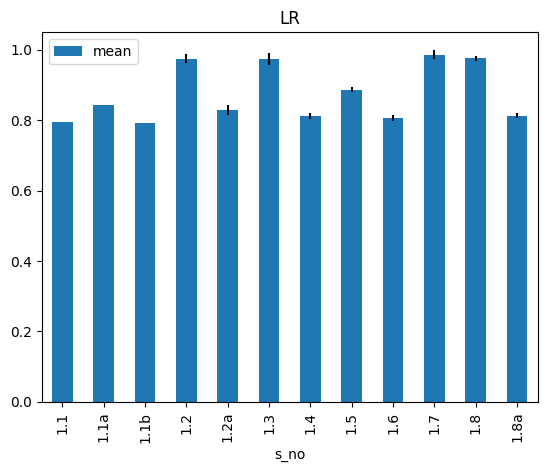

In [51]:
set = "HD"

# model_names = ["LR", "SVM", "DT", "RF", "XGB"]

model_names = ["LR"]

n_models = [50, 60, 70, 80, 90, 100]

for model in model_names:

    results_path = set+"/Final_Results/"+model

    plot_results_model_wise(path=results_path, results_for = model, set = set)

# for n_model in n_models:
    
#     results_for = str(n_model)+"_"+model_name

#     plot_results_model_wise(path=results_path, results_for = results_for)

In [40]:
!pwd

/Users/bhavesh/Documents/AU/PhD/model_agreement_expr/gitrepo/model_agreement
